## 0. Setup

In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# ==== EDIT THESE PATHS ====
DATA_DIR = "/content/drive/MyDrive/HAM0000"        # folder containing metadata csv + image folders
METADATA_CSV = f"{DATA_DIR}/metadata/HAM10000_final.csv"
IMAGE_DIRS = ["/content/HAM10000"]


OUTPUT_DIR = "/content/drive/MyDrive/outputs"
APPLY_SEGMENTATION_MASK = False   # see note above — paper is ambiguous, default off
IMG_HEIGHT, IMG_WIDTH = 224, 224   # per Table 3: input size (75 x 100 x 3)
BATCH_SIZE = 32
MAX_EPOCHS = 120
EARLY_STOP_PATIENCE = 10
LEARNING_RATE = 1e-5
MAX_PER_CLASS = 3500
SEED = 42

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [ ]:

import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

tf.random.set_seed(SEED)
np.random.seed(SEED)
print("GPU available:", tf.config.list_physical_devices('GPU'))


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



### W&B login

One login for the whole notebook — each model (DenseNet201/InceptionV3/VGG16) will get its own
**run** inside a shared **project**, so you can compare their loss/accuracy curves side by side
in the W&B dashboard instead of only looking at the inline matplotlib plots in cell 8.


In [ ]:

import wandb
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint

wandb.login()  # paste your API key when prompted (https://wandb.ai/authorize)

WANDB_PROJECT = "BNC20000"
WANDB_ENTITY = None  # set to your team/username, or leave None for your default entity


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: khoaanh05 (khoaanh05-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 1. Load metadata and build lesion-wise splits (prevents data leakage — Section 3.1)

In [ ]:
def find_image_path(isic_id):
    for d in IMAGE_DIRS:
        p = os.path.join(d, isic_id + ".jpg")
        if os.path.exists(p):
            return p
    return None

meta = pd.read_csv(METADATA_CSV)
meta["path"] = meta["isic_id"].apply(find_image_path)
missing = meta["path"].isna().sum()
if missing:
    print(f"WARNING: {missing} images not found on disk — check IMAGE_DIRS.")
meta = meta.dropna(subset=["path"]).reset_index(drop=True)

CLASS_NAMES = ["NV", "MEL", "BKL", "BCC", "AK", "VASC", "DF", "SCC"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
meta["label"] = meta["label"].map(CLASS_TO_IDX)
print(meta["label"].value_counts())

# ---- metadata cleanup (raw only — no fitting here, fitting happens after split
# to avoid leaking train-set statistics into val/test) ----
meta["age_approx"] = pd.to_numeric(meta["age_approx"], errors="coerce")
meta["sex"] = meta["sex"].fillna("unknown").astype(str).str.lower()
meta["anatom_site_final"] = meta["anatom_site_final"].fillna("unknown").astype(str).str.lower()
print("age_approx missing:", round(float(meta["age_approx"].isna().mean()), 3))
print("sex values:", meta["sex"].value_counts().to_dict())
print("anatom_site_final values:", meta["anatom_site_final"].value_counts().to_dict())

label
0    5647
1    4636
3    3676
2    1551
4    1088
7     559
6     168
5     151
Name: count, dtype: int64
age_approx missing: 0.007
sex values: {'male': 9056, 'female': 8305, 'unknown': 115}
anatom_site_final values: {'anterior trunk': 7073, 'head and neck': 4458, 'lower extremity': 3243, 'upper extremity': 1778, 'acral palms or soles': 596, 'unknown': 265, 'oral or genital': 63}


In [ ]:
from sklearn.model_selection import train_test_split

# 80% train+val, 20% test
train_val_df, test_df = train_test_split(
    meta,
    test_size=0.20,
    stratify=meta["label"],
    random_state=SEED
)

# Từ 80% còn lại lấy 10% tổng làm validation
# 10 / 80 = 0.125
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.125,
    stratify=train_val_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print("Train")
print(train_df["label"].value_counts())

print("Validation")
print(val_df["label"].value_counts())

print("Test")
print(test_df["label"].value_counts())


Train
label
0    3952
1    3245
3    2574
2    1086
4     761
7     391
6     117
5     106
Name: count, dtype: int64
Validation
label
0    565
1    464
3    367
2    155
4    109
7     56
6     17
5     15
Name: count, dtype: int64
Test
label
0    1130
1     927
3     735
2     310
4     218
7     112
6      34
5      30
Name: count, dtype: int64


In [ ]:
# ==== Metadata feature encoding (fit ONLY on train_df — val/test must not leak stats) ====
# age_approx: numeric -> median-impute (train median) -> z-score (train mean/std)
AGE_MEDIAN = train_df["age_approx"].median()
AGE_MEAN = train_df["age_approx"].fillna(AGE_MEDIAN).mean()
AGE_STD = train_df["age_approx"].fillna(AGE_MEDIAN).std()

# sex / anatom_site_final: one-hot, vocabulary built from TRAIN ONLY.
# Any category seen in val/test but not train collapses into "unknown" —
# this WILL happen for anatom_site_final if BCN20000's rarer sites split unevenly,
# so don't be surprised if val/test show a spike in the unknown bucket versus train.
SEX_CATEGORIES = sorted(train_df["sex"].unique().tolist())
SITE_CATEGORIES = sorted(train_df["anatom_site_final"].unique().tolist())
if "unknown" not in SEX_CATEGORIES:
    SEX_CATEGORIES.append("unknown")
if "unknown" not in SITE_CATEGORIES:
    SITE_CATEGORIES.append("unknown")

def _onehot(value, categories):
    vec = np.zeros(len(categories), dtype=np.float32)
    idx = categories.index(value) if value in categories else categories.index("unknown")
    vec[idx] = 1.0
    return vec

def encode_metadata_row(row):
    age = row["age_approx"]
    age = AGE_MEDIAN if pd.isna(age) else age
    age_z = np.float32((age - AGE_MEAN) / (AGE_STD + 1e-6))
    sex_vec = _onehot(row["sex"], SEX_CATEGORIES)
    site_vec = _onehot(row["anatom_site_final"], SITE_CATEGORIES)
    return np.concatenate([[age_z], sex_vec, site_vec]).astype(np.float32)

def encode_metadata_df(df):
    return np.stack([encode_metadata_row(r) for _, r in df.iterrows()])

META_DIM = 1 + len(SEX_CATEGORIES) + len(SITE_CATEGORIES)
print(f"META_DIM = {META_DIM} (1 age + {len(SEX_CATEGORIES)} sex + {len(SITE_CATEGORIES)} site)")

train_meta = encode_metadata_df(train_df)
val_meta = encode_metadata_df(val_df)
test_meta = encode_metadata_df(test_df)

META_DIM = 11 (1 age + 3 sex + 7 site)


## 2. Preprocessing (Section 3.2 / Figure 2): denoise → contrast → hair removal → resize

In [ ]:
def hist_eq_yuv(img):
    # equalize luminance channel only, preserve color (paper: YUV Y-channel equalizeHist)
    yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    yuv[:,:,0] = clahe.apply(yuv[:,:,0])

    return cv2.cvtColor(yuv, cv2.COLOR_YUV2BGR)

def remove_hair_dullrazor(img):
    # DullRazor-style: grayscale -> blackhat morphology -> threshold -> inpaint
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    plt.imshow(mask,cmap="gray")
    return cv2.inpaint(img, mask, 7, cv2.INPAINT_TELEA)

def otsu_mask(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return mask

def preprocess_image(path):
    img = cv2.imread(path)  # BGR
    img = remove_hair_dullrazor(img)
    img = hist_eq_yuv(img)
    if APPLY_SEGMENTATION_MASK:
        mask = otsu_mask(img)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
          c = max(contours, key=cv2.contourArea)
          x, y, w, h = cv2.boundingRect(c)

          # thêm một ít margin
          pad = 10
          x = max(0, x - pad)
          y = max(0, y - pad)
          w = min(img.shape[1] - x, w + 2 * pad)
          h = min(img.shape[0] - y, h + 2 * pad)

          img = img[y:y+h, x:x+w]
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_AREA)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.astype(np.float32) / 255.0


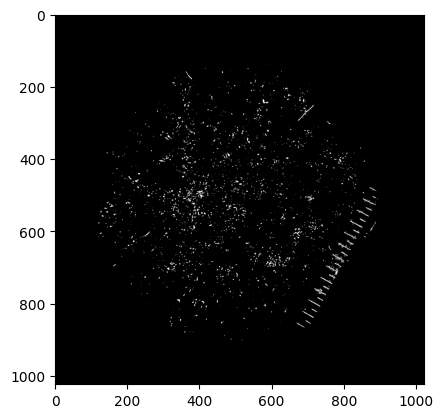

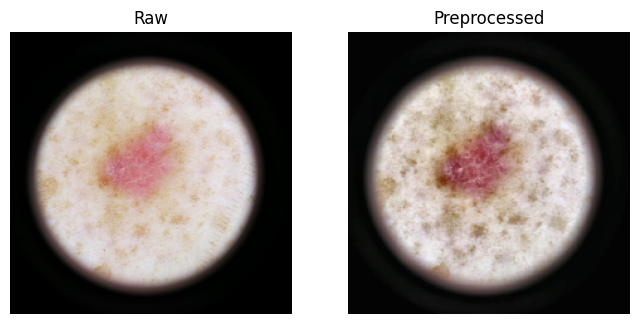

In [ ]:

# quick visual sanity check on one sample
sample_path = train_df.iloc[0]["path"]
raw = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
proc = (preprocess_image(sample_path) * 255).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(raw); ax[0].set_title("Raw"); ax[0].axis("off")
ax[1].imshow(proc); ax[1].set_title("Preprocessed"); ax[1].axis("off")
plt.show()


## 3. Class balancing for training (Table 2: cap 3,500/class, augment minority classes)

In [ ]:
AUGMENTER = tf.keras.Sequential([
    layers.RandomRotation(0.15),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
])

def build_balanced_training_index(df, meta_arr, max_per_class=MAX_PER_CLASS, seed=SEED):
    rng = np.random.default_rng(seed)
    entries = []
    for label_idx, cls in enumerate(CLASS_NAMES):
        sub_mask = (df["label"] == label_idx).to_numpy()
        sub_positions = np.where(sub_mask)[0]  # positions into df/meta_arr, not df.index
        n = len(sub_positions)
        if n >= max_per_class:
            chosen = rng.choice(sub_positions, size=max_per_class, replace=False)
            entries += [(df["path"].iloc[p], label_idx, False, meta_arr[p]) for p in chosen]
        else:
            entries += [(df["path"].iloc[p], label_idx, False, meta_arr[p]) for p in sub_positions]
            n_needed = max_per_class - n
            extra = rng.choice(sub_positions, size=n_needed, replace=True)
            entries += [(df["path"].iloc[p], label_idx, True, meta_arr[p]) for p in extra]
    rng.shuffle(entries)
    return entries

train_entries = build_balanced_training_index(train_df, train_meta)
print(f"Balanced training set size: {len(train_entries)} (target {MAX_PER_CLASS*7})")

Balanced training set size: 28000 (target 24500)


In [ ]:
def make_dataset(entries_or_df, training, batch_size=BATCH_SIZE, is_df=False, meta_arr=None):
    if is_df:
        paths = entries_or_df["path"].tolist()
        labels = entries_or_df["label"].tolist()
        aug_flags = [False] * len(paths)
        metas = meta_arr  # already aligned array, shape (N, META_DIM)
    else:
        paths = [e[0] for e in entries_or_df]
        labels = [e[1] for e in entries_or_df]
        aug_flags = [e[2] for e in entries_or_df]
        metas = np.stack([e[3] for e in entries_or_df])

    def _load(path, label, aug_flag, meta_vec):
        def _py_load(p):
            return preprocess_image(p.numpy().decode("utf-8"))
        img = tf.py_function(_py_load, [path], tf.float32)
        img.set_shape([IMG_HEIGHT, IMG_WIDTH, 3])
        meta_vec.set_shape([META_DIM])
        return (img, meta_vec), tf.one_hot(label, depth=7)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels, aug_flags, metas.astype(np.float32)))
    ds = ds.map(lambda p, l, a, m: _load(p, l, a, m), num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(2048, seed=SEED)
        # only augment the image branch — metadata passes through unchanged
        ds = ds.map(lambda x, y: ((AUGMENTER(x[0], training=True), x[1]), y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_entries, training=True)
val_ds = make_dataset(val_df, training=False, is_df=True, meta_arr=val_meta)
test_ds = make_dataset(test_df, training=False, is_df=True, meta_arr=test_meta)


## 4. Model definitions — Technique 2 (fine-tune back half of backbone + custom head)

Following the **prose** description in Section 3.4/3.5 (not Figures 6/7 — see deviation note in cell 1):
freeze the first half of the backbone's layers, unfreeze the back half, append
`GlobalAveragePooling2D → Dense(512, relu) → Dropout(0.5) → Dense(7, softmax)`.


In [ ]:
def build_finetuned_model(backbone_fn, name):
    backbone = backbone_fn(weights="imagenet", include_top=False,
                            input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    n_layers = len(backbone.layers)
    freeze_until = n_layers // 2
    for i, layer in enumerate(backbone.layers):
        layer.trainable = i >= freeze_until

    img_feat = backbone.output
    img_feat = layers.GlobalAveragePooling2D()(img_feat)

    meta_input = layers.Input(shape=(META_DIM,), name="metadata_input")
    meta_feat = layers.Dense(64, activation="relu")(meta_input)
    meta_feat = layers.Dropout(0.3)(meta_feat)
    meta_feat = layers.Dense(32, activation="relu")(meta_feat)

    x = layers.Concatenate()([img_feat, meta_feat])
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(7, activation="softmax")(x)
    model = models.Model([backbone.input, meta_input], out, name=name)
    return model

def compile_model(model):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [ ]:

def get_callbacks(model_name, use_wandb=True):
    backup_dir = f"{OUTPUT_DIR}/backup_{model_name}"
    cbs = [
        callbacks.BackupAndRestore(backup_dir=backup_dir),  # resume training state after disconnect
        callbacks.EarlyStopping(monitor="val_loss", patience=EARLY_STOP_PATIENCE, restore_best_weights=True, verbose=1),
        callbacks.ModelCheckpoint(f"{OUTPUT_DIR}/{model_name}.h5", monitor="val_loss", save_best_only=True, verbose=1),
        callbacks.ModelCheckpoint(filepath=f"{OUTPUT_DIR}/{model_name}.keras", monitor="val_loss", mode="min", save_best_only=True, verbose=1),
        callbacks.CSVLogger(f"{OUTPUT_DIR}/{model_name}_history.csv", append=True),  # append=True: don't clobber rows already logged before disconnect
    ]
    if use_wandb:
        cbs.append(WandbMetricsLogger(log_freq="epoch"))
        cbs.append(WandbModelCheckpoint(filepath=f"{OUTPUT_DIR}/{model_name}_wandb.keras",
                                         monitor="val_loss", save_best_only=True))
    return cbs

def train_model(backbone_fn, keras_module_name, model_name, use_wandb=True):
    if use_wandb:
        run = wandb.init(
            project=WANDB_PROJECT, entity=WANDB_ENTITY, name=model_name, reinit=True,
            config=dict(
                backbone=keras_module_name, technique="technique2_unfreeze_back_half",
                img_height=IMG_HEIGHT, img_width=IMG_WIDTH, batch_size=BATCH_SIZE,
                max_epochs=MAX_EPOCHS, early_stop_patience=EARLY_STOP_PATIENCE,
                learning_rate=LEARNING_RATE, max_per_class=MAX_PER_CLASS, seed=SEED,
                apply_segmentation_mask=APPLY_SEGMENTATION_MASK,
            ),
        )
    model = build_finetuned_model(backbone_fn, model_name)
    compile_model(model)
    print(model.summary())
    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=MAX_EPOCHS, callbacks=get_callbacks(model_name, use_wandb=use_wandb),
    )
    if use_wandb:
        wandb.finish()
    return model, history


## 5. Train DenseNet201

In [ ]:

from tensorflow.keras.applications import DenseNet201
densenet_model, densenet_hist = train_model(DenseNet201, "densenet201", "densenet201_finetuned")


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Model: "densenet201_finetuned"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 19,328,359 (73.73 MB)

 Trainable params: 13,745,639 (52.44 MB)

 Non-trainable params: 5,582,720 (21.30 MB)

wandb: WARNING When using `save_best_only`, ensure that the `filepath` argument contains formatting placeholders like `{epoch:02d}` or `{batch:02d}`. This ensures correct interpretation of the logged artifacts.


None
Epoch 1/120
 85/875 ━━━━━━━━━━━━━━━━━━━━ 1:13:40 6s/step - accuracy: 0.1558 - loss: 1.9505

## 6. Train InceptionV3

In [ ]:

from tensorflow.keras.applications import InceptionV3
inception_model, inception_hist = train_model(InceptionV3, "inceptionv3", "inceptionv3_finetuned")


## 7. Train VGG16

In [ ]:

from tensorflow.keras.applications import VGG16
vgg_model, vgg_hist = train_model(VGG16, "vgg16", "vgg16_finetuned")


## 8. Training curves

In [ ]:

def plot_history(hist, name):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].plot(hist.history["accuracy"], label="train"); ax[0].plot(hist.history["val_accuracy"], label="val")
    ax[0].set_title(f"{name} accuracy"); ax[0].legend()
    ax[1].plot(hist.history["loss"], label="train"); ax[1].plot(hist.history["val_loss"], label="val")
    ax[1].set_title(f"{name} loss"); ax[1].legend()
    plt.show()

plot_history(densenet_hist, "DenseNet201")
plot_history(inception_hist, "InceptionV3")
plot_history(vgg_hist, "VGG16")


## 9. Soft-voting ensemble (Section 3.4) + evaluation on held-out lesion-wise test set

In [ ]:

def get_probs_and_labels(model, ds):
    probs, labels = [], []
    for x, y in ds:
        probs.append(model.predict(x, verbose=0))
        labels.append(y.numpy())
    return np.concatenate(probs), np.concatenate(labels)

p_dense, y_true_oh = get_probs_and_labels(densenet_model, test_ds)
p_incep, _ = get_probs_and_labels(inception_model, test_ds)
p_vgg, _ = get_probs_and_labels(vgg_model, test_ds)

y_true = np.argmax(y_true_oh, axis=1)
ensemble_probs = (p_dense + p_incep + p_vgg) / 3.0
y_pred_ensemble = np.argmax(ensemble_probs, axis=1)

def report(y_true, y_pred, name):
    print(f"=== {name} ===")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
    acc = (y_true == y_pred).mean()
    print(f"Overall accuracy: {acc:.4f}")
    return acc

for probs, name in [(p_dense, "DenseNet201"), (p_incep, "InceptionV3"), (p_vgg, "VGG16")]:
    report(y_true, np.argmax(probs, axis=1), name)

ensemble_acc = report(y_true, y_pred_ensemble, "Soft-Voting Ensemble")


In [ ]:

cm = confusion_matrix(y_true, y_pred_ensemble)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Ensemble confusion matrix (held-out test set)")
plt.show()


In [ ]:
def find_gap_input(model):
    for layer in model.layers:
        if isinstance(layer, layers.GlobalAveragePooling2D):
            return layer.input
    raise ValueError("Không tìm thấy GlobalAveragePooling2D trong model")

def make_gradcam_model(model):
    conv_output = find_gap_input(model)
    return models.Model(inputs=model.input, outputs=[conv_output, model.output])

def grad_cam(model, img_array, meta_array, class_idx=None):
    grad_model = make_gradcam_model(model)
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model([img_array, meta_array])
        if class_idx is None:
            class_idx = int(tf.argmax(preds[0]))
        loss = preds[:, class_idx]
    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), class_idx

def overlay_gradcam(raw_img_rgb, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (raw_img_rgb.shape[1], raw_img_rgb.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    return np.uint8(colored * alpha + raw_img_rgb * (1 - alpha))

# ví dụ chạy trên 1 sample test
sample_row = test_df.iloc[0]
img = preprocess_image(sample_row["path"])                 # đã qua hair-removal + hist eq
meta_vec = encode_metadata_row(sample_row)
heatmap, pred_class = grad_cam(
    densenet_model,                       # đổi thành inception_model / vgg_model tuỳ ý
    img[np.newaxis, ...], meta_vec[np.newaxis, ...],
)
raw_img = cv2.cvtColor(cv2.imread(sample_row["path"]), cv2.COLOR_BGR2RGB)
overlay = overlay_gradcam(cv2.resize(raw_img, (IMG_WIDTH, IMG_HEIGHT)), heatmap)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(raw_img); ax[0].set_title(f"Raw — true: {CLASS_NAMES[sample_row['label']]}"); ax[0].axis("off")
ax[1].imshow(overlay); ax[1].set_title(f"Grad-CAM — pred: {CLASS_NAMES[pred_class]}"); ax[1].axis("off")
plt.show()

In [ ]:
def specificity_per_class(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    specs = {}
    total = cm.sum()
    for i, cls in enumerate(class_names):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total - tp - fn - fp
        specs[cls] = tn / (tn + fp + 1e-8)
    return specs

specs = specificity_per_class(y_true, y_pred_ensemble, CLASS_NAMES)
for cls, s in specs.items():
    print(f"{cls:6s} specificity: {s:.4f}")